In [ ]:
from google.colab import files
uploaded = files.upload()

Saving income.csv to income.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv('income.csv')
display(df.head())

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_level
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0


In [ ]:
# Identify categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(exclude=['object']).columns

# Exclude the target variable if it's in categorical_features
if 'income_level' in categorical_features:
    categorical_features = categorical_features.drop('income_level')

# Apply one-hot encoding to categorical features (excluding target)
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Encode the target variable 'income_level'
le = LabelEncoder()
df_encoded['income_level'] = le.fit_transform(df_encoded['income_level'])

# Define features (X) and target (y)
X = df_encoded.drop('income_level', axis=1)
y = df_encoded['income_level']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (34189, 6)
Shape of X_test: (14653, 6)


In [ ]:
# Initialize the base estimator (Decision Tree Classifier)
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize AdaBoost Classifier with n_estimators=10
adaboost_clf_initial = AdaBoostClassifier(estimator=base_estimator, n_estimators=10, random_state=42)

# Train the model
adaboost_clf_initial.fit(X_train, y_train)

# Make predictions on the test set
y_pred_initial = adaboost_clf_initial.predict(X_test)

# Calculate the accuracy score
accuracy_initial = accuracy_score(y_test, y_pred_initial)

print(f"AdaBoost Classifier (n_estimators=10) Accuracy: {accuracy_initial:.4f}")

AdaBoost Classifier (n_estimators=10) Accuracy: 0.8277


In [ ]:
import numpy as np

# Define a range of n_estimators to test
n_estimators_range = np.arange(10, 201, 10) # From 10 to 200, step 10

best_score = 0
best_n_estimators = 0

# Store scores for plotting later if needed
scores = []

for n in n_estimators_range:
    adaboost_clf = AdaBoostClassifier(estimator=base_estimator, n_estimators=n, random_state=42)
    adaboost_clf.fit(X_train, y_train)
    y_pred = adaboost_clf.predict(X_test)
    current_score = accuracy_score(y_test, y_pred)
    scores.append(current_score)

    if current_score > best_score:
        best_score = current_score
        best_n_estimators = n

print(f"Best score: {best_score:.4f}")
print(f"Best n_estimators: {best_n_estimators}")

Best score: 0.8312
Best n_estimators: 160


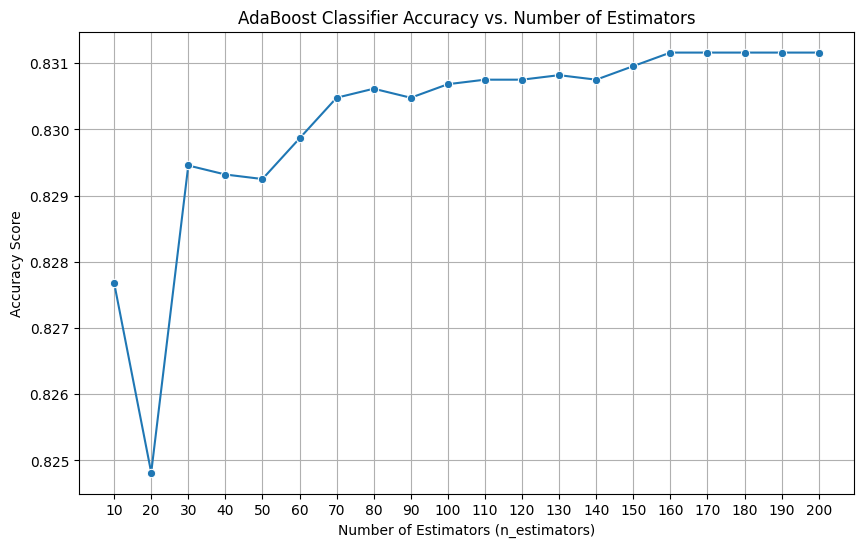

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x=n_estimators_range, y=scores, marker='o')
plt.title('AdaBoost Classifier Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy Score')
plt.xticks(n_estimators_range)
plt.grid(True)
plt.show()